# Bab 2 — Data and Sampling Distributions
**Practical Statistics for Data Scientists, 2nd Edition** — Peter Bruce, Andrew Bruce & Peter Gedeck (O'Reilly, 2020)

1. Random sampling dan sample bias
2. Selection bias & regression to the mean
3. Sampling distribution sebuah statistik (CLT, standard error)
4. Bootstrap
5. Confidence interval
6. Distribusi normal & QQ-plot
7. Distribusi long-tailed
8. Distribusi t (Student's t)
9. Distribusi binomial
10. Distribusi chi-square dan F
11. Distribusi Poisson, eksponensial, dan Weibull

In [1]:
!pip install statsmodels

In [2]:
%matplotlib inline
import pandas as pd
import numpy as np
from scipy import stats
from sklearn.utils import resample
import seaborn as sns
import matplotlib.pyplot as plt

DATA = 'https://raw.githubusercontent.com/gedeck/practical-statistics-for-data-scientists/master/data/'

## Gambaran Besar: Populasi vs Sampel

Di era big data, orang sering mengira sampling tidak diperlukan lagi. Kenyataannya justru sebaliknya: data besar sering berkualitas tidak merata, penuh bias, dan mahal diolah. Sampling yang baik tetap penting, misalnya untuk membangun dan menguji model secara efisien.

Alur berpikirnya:
- Ada **populasi** dengan distribusi yang biasanya *tidak diketahui*.
- Kita hanya punya **sampel** dari populasi itu.
- Dari sampel, kita ingin menarik kesimpulan tentang populasi, sekaligus tahu **seberapa besar ketidakpastiannya**.

Bab ini membahas dua hal: (1) cara mengambil sampel yang baik, dan (2) cara mengukur variabilitas estimasi yang dihitung dari sampel.

## 1. Random Sampling dan Sample Bias

**Istilah kunci:**
- **Sample** — subset dari dataset yang lebih besar.
- **Population** — dataset lengkap (bisa nyata atau teoretis/imajiner).
- **N (n)** — ukuran populasi (sampel).
- **Random sampling** — setiap anggota populasi punya peluang sama untuk terpilih.
- **Stratified sampling** — populasi dibagi ke *strata* (kelompok), lalu diambil sampel acak dari tiap strata.
- **Simple random sample** — sampel acak tanpa stratifikasi.
- **Bias** — kesalahan sistematis.
- **Sample bias** — sampel tidak mewakili populasi.

**Contoh klasik (dari buku):** Survei *Literary Digest* tahun 1936 memprediksi Alf Landon mengalahkan Franklin Roosevelt, padahal Roosevelt menang telak. Survei itu menjangkau lebih dari 10 juta orang, tapi daftar respondennya diambil dari pelanggan majalah, pemilik telepon, dan pemilik mobil, yang pada masa Depresi cenderung kelompok berada. Sementara George Gallup, dengan hanya sekitar 2.000 responden yang dipilih secara acak, menebak dengan benar.

**Pelajaran:** *kualitas* sampel lebih penting daripada *ukuran*-nya.

### Bias vs Random Error
- **Random error**: meleset ke segala arah secara acak.
- **Bias**: meleset secara konsisten ke satu arah. Biasanya tanda bahwa model atau cara sampling-nya salah.

### Ukuran vs Kualitas
Sampel kecil tapi acak dan bersih sering lebih berguna daripada data besar yang kotor. Data besar tetap berguna ketika datanya **jarang (sparse)**, misalnya kueri pencarian yang langka: hanya dengan data sangat besar kita punya cukup contoh untuk kueri seperti itu.

### Sample Mean vs Population Mean
- $\bar{x}$ = rata-rata **sampel** (dihitung dari data).
- $\mu$ = rata-rata **populasi** (biasanya tidak diketahui, hanya bisa diestimasi).

In [3]:
# Ilustrasi stratified vs simple random sampling
rng = np.random.default_rng(42)
pop = pd.DataFrame({'kelompok': rng.choice(['A', 'B', 'C'], size=10_000, p=[0.7, 0.2, 0.1])})

simple = pop.sample(100, random_state=1)
strat = pop.groupby('kelompok').sample(frac=0.01, random_state=1)

print('Proporsi populasi:\n', pop['kelompok'].value_counts(normalize=True).round(3))
print('\nSimple random sample:\n', simple['kelompok'].value_counts(normalize=True).round(3))
print('\nStratified sample:\n', strat['kelompok'].value_counts(normalize=True).round(3))

Proporsi populasi:
 kelompok
A    0.706
B    0.196
C    0.098
Name: proportion, dtype: float64

Simple random sample:
 kelompok
A    0.70
B    0.21
C    0.09
Name: proportion, dtype: float64

Stratified sample:
 kelompok
A    0.703
B    0.198
C    0.099
Name: proportion, dtype: float64


Stratified sampling menjamin tiap kelompok terwakili sesuai proporsinya. Teknik ini juga bisa dipakai untuk sengaja memperbanyak (*oversample*) kelompok kecil supaya estimasinya lebih stabil.

## 2. Selection Bias

**Selection bias** = memilih data secara sadar atau tidak sadar dengan cara yang mengarah ke kesimpulan menyesatkan.

**Istilah kunci:**
- **Data snooping** — mengubek-ubek data terlalu lama sampai "menemukan" sesuatu yang menarik.
- **Vast search effect** — kalau mencoba sangat banyak model/pertanyaan, pasti ada yang terlihat signifikan hanya karena kebetulan.

**Contoh:** kalau 20.000 orang melempar koin 10 kali, kemungkinan besar ada beberapa orang yang dapat 10 kali "gambar" berturut-turut. Itu bukan bakat, hanya efek dari banyaknya percobaan.

**Cara mengurangi:** gunakan **holdout set** (data yang disisihkan untuk validasi), bahkan lebih dari satu, dan uji ulang temuan dengan data baru. Teknik **target shuffling** (mengacak variabel target lalu melihat apakah model tetap "menemukan" pola) juga membantu.

Bentuk lain selection bias: memilih periode waktu yang mendukung kesimpulan tertentu, menghentikan eksperimen ketika hasilnya "bagus", atau hanya melaporkan hasil yang menarik.

### Regression to the Mean
Kalau kita memilih kasus ekstrem (misalnya performa terbaik), pengukuran berikutnya cenderung **kembali mendekati rata-rata**. Contoh terkenal: *rookie of the year* di olahraga sering tampil lebih buruk di musim kedua (*sophomore slump*). Performa ekstrem biasanya gabungan dari kemampuan + keberuntungan, dan keberuntungan itu tidak berulang.

Istilah "regression" dalam regresi linear sebenarnya berasal dari fenomena ini (Francis Galton mengamati tinggi badan anak dari orang tua yang sangat tinggi cenderung lebih mendekati rata-rata).

In [4]:
# Simulasi regression to the mean: skor = kemampuan + keberuntungan
rng = np.random.default_rng(0)
n = 1000
kemampuan = rng.normal(50, 10, n)
musim1 = kemampuan + rng.normal(0, 10, n)
musim2 = kemampuan + rng.normal(0, 10, n)

top = musim1 >= np.percentile(musim1, 95)   # 5% terbaik di musim 1
print(f'Rata-rata top 5% di musim 1: {musim1[top].mean():.1f}')
print(f'Rata-rata kelompok yang sama di musim 2: {musim2[top].mean():.1f}')
print(f'Rata-rata semua pemain: {musim1.mean():.1f}')

Rata-rata top 5% di musim 1: 78.9
Rata-rata kelompok yang sama di musim 2: 63.9
Rata-rata semua pemain: 49.4


## 3. Sampling Distribution sebuah Statistik

**Istilah kunci:**
- **Sample statistic** — angka yang dihitung dari sampel (misalnya mean).
- **Data distribution** — distribusi dari *nilai-nilai individual* dalam dataset.
- **Sampling distribution** — distribusi dari *statistik sampel* jika kita mengambil banyak sampel berulang kali.
- **Central limit theorem (CLT)** — sampling distribution cenderung berbentuk normal ketika ukuran sampel membesar.
- **Standard error (SE)** — standar deviasi dari sampling distribution.

**Intinya:** statistik yang dihitung dari sampel pasti bervariasi dari sampel ke sampel. Distribusi dari statistik itu biasanya:
- lebih **sempit** daripada distribusi datanya, dan
- lebih **berbentuk lonceng (normal)**, terutama jika sampelnya besar.

Contoh dari buku: pendapatan tahunan pemohon pinjaman di LendingClub. Kita bandingkan tiga hal:
1. Sampel 1.000 nilai individual,
2. 1.000 mean dari sampel berukuran 5,
3. 1.000 mean dari sampel berukuran 20.

In [5]:
loans_income = pd.read_csv(DATA + 'loans_income.csv').squeeze('columns')

sample_data = pd.DataFrame({'income': loans_income.sample(1000), 'type': 'Data'})
sample_mean_05 = pd.DataFrame({
    'income': [loans_income.sample(5).mean() for _ in range(1000)],
    'type': 'Mean of 5'})
sample_mean_20 = pd.DataFrame({
    'income': [loans_income.sample(20).mean() for _ in range(1000)],
    'type': 'Mean of 20'})
results = pd.concat([sample_data, sample_mean_05, sample_mean_20])
results.groupby('type')['income'].agg(['mean', 'std']).round(0)

,mean,std
type,,
Data,67854.0,32850.0
Mean of 20,69110.0,7242.0
Mean of 5,68260.0,14865.0


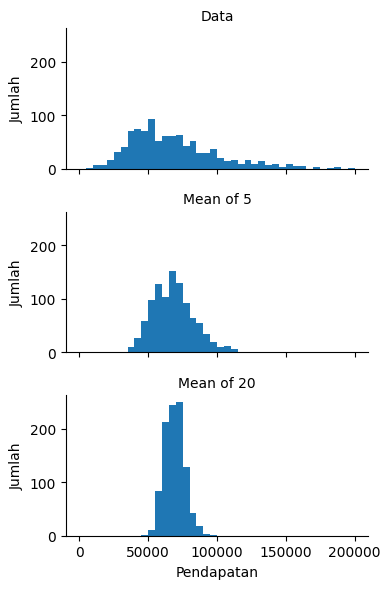

In [6]:
# Figure 2-6
g = sns.FacetGrid(results, col='type', col_wrap=1, height=2, aspect=2)
g.map(plt.hist, 'income', range=[0, 200000], bins=40)
g.set_axis_labels('Pendapatan', 'Jumlah')
g.set_titles('{col_name}')
plt.tight_layout(); plt.show()

Terlihat: semakin besar ukuran sampel, distribusi mean semakin sempit dan semakin simetris. Inilah **central limit theorem** dalam praktik.

### Central Limit Theorem
Rata-rata dari banyak sampel akan membentuk kurva normal, **bahkan jika populasinya tidak normal**, asalkan ukuran sampel cukup besar dan datanya tidak terlalu jauh dari normal. CLT adalah dasar rumus-rumus klasik untuk uji hipotesis dan confidence interval.

Buku menekankan: di data science, CLT **tidak terlalu sentral**, karena uji hipotesis formal dan confidence interval tidak sering dipakai, dan **bootstrap** tersedia sebagai alternatif.

### Standard Error
$$SE = \frac{s}{\sqrt{n}}$$
- $s$ = standar deviasi sampel, $n$ = ukuran sampel.
- Makin besar $n$, makin kecil SE. Ini disebut **square-root of n rule**: untuk memperkecil SE setengahnya, ukuran sampel harus dinaikkan **4 kali lipat**.

**Jangan tertukar:**
- **Standard deviation** → variabilitas *data individual*.
- **Standard error** → variabilitas *statistik sampel*.

Cara empiris mengukur SE: ambil banyak sampel baru dan lihat sebarannya. Tapi mengambil sampel baru di dunia nyata sering mahal/mustahil, dan di sinilah **bootstrap** berguna.

In [7]:
# Cek rumus SE dengan simulasi
n = 20
se_rumus = loans_income.std() / np.sqrt(n)
se_simulasi = sample_mean_20['income'].std()
print(f'SE dari rumus    : {se_rumus:,.0f}')
print(f'SE dari simulasi : {se_simulasi:,.0f}')

SE dari rumus    : 7,350
SE dari simulasi : 7,242


## 4. Bootstrap

**Bootstrap** = mengambil sampel **dengan pengembalian (with replacement)** dari data yang kita punya, berulang kali, untuk mengestimasi sampling distribution sebuah statistik.

Ide dasarnya: bayangkan sampel kita disalin ribuan kali sehingga menjadi "populasi tiruan". Mengambil sampel dengan pengembalian setara dengan mengambil sampel dari populasi tiruan itu.

**Algoritma bootstrap untuk mean (sampel berukuran $n$):**
1. Ambil satu nilai secara acak, catat, lalu kembalikan.
2. Ulangi $n$ kali.
3. Hitung mean dari $n$ nilai tersebut.
4. Ulangi langkah 1–3 sebanyak $R$ kali.
5. Gunakan $R$ hasil itu untuk:
   - menghitung standar deviasinya (= estimasi standard error),
   - membuat histogram/boxplot,
   - menghitung confidence interval.

**Kelebihan:**
- Tidak butuh asumsi bahwa statistiknya berdistribusi normal.
- Bisa dipakai untuk statistik apa pun (median, rasio, koefisien model), termasuk yang tidak punya rumus SE.
- Bisa dipakai untuk data multivariat (ambil sampel per baris).

**Batasan:** bootstrap **tidak** menambah data dan tidak memperbaiki sampel yang kecil atau bias. Ia hanya memberi tahu seberapa besar variasi yang muncul jika sampel diambil ulang dari populasi yang mirip sampel kita.

**Bootstrap dalam machine learning:** menjalankan model (misalnya decision tree) pada banyak sampel bootstrap lalu menggabungkan prediksinya disebut **bagging** (*bootstrap aggregating*), yang merupakan dasar Random Forest (lihat Bab 6).

In [8]:
# Bootstrap untuk median pendapatan
results = []
for nrepeat in range(1000):
    sample = resample(loans_income)
    results.append(sample.median())
results = pd.Series(results)

print('Bootstrap statistics:')
print(f'original : {loans_income.median()}')
print(f'bias     : {results.mean() - loans_income.median()}')
print(f'std. error: {results.std():.2f}')

Bootstrap statistics:
original : 62000.0
bias     : -66.70350000000326
std. error: 205.89


Hasilnya: estimasi bias sangat kecil, dan standard error median sekitar 200-an dolar. Tidak ada rumus sederhana untuk SE median, tapi bootstrap memberi jawabannya dengan mudah.

### Resampling vs Bootstrapping
- **Resampling** adalah istilah umum untuk mengambil sampel berulang dari data yang ada, termasuk bootstrap dan **permutation test** (Bab 3).
- **Permutation** biasanya **tanpa** pengembalian, dipakai untuk menggabungkan beberapa kelompok dan menguji apakah perbedaannya nyata.
- **Bootstrap** selalu **dengan** pengembalian.

## 5. Confidence Interval

**Confidence interval (CI)** = rentang nilai yang memberi gambaran ketidakpastian sebuah estimasi. Contoh: *CI 90%* adalah rentang yang mencakup 90% sampling distribution dari statistik tersebut.

**Istilah kunci:**
- **Confidence level** — persentase CI yang diharapkan memuat nilai sebenarnya jika prosedur diulang berkali-kali (misalnya 90%, 95%).
- **Interval endpoints** — batas bawah dan atas CI.

**Cara membuat CI dengan bootstrap (persentil):**
1. Ambil sampel bootstrap sebanyak $R$ kali dan hitung statistiknya tiap kali.
2. Untuk CI $x$%, potong $\frac{100 - x}{2}$% dari tiap ujung distribusi hasil bootstrap.
3. Titik potongnya adalah batas CI.

**Interpretasi yang sering salah:** CI 95% **tidak** berarti "ada peluang 95% nilai sebenarnya berada di interval ini". Yang tepat: jika prosedur pengambilan sampel dan pembuatan CI diulang berkali-kali, sekitar 95% interval yang dihasilkan akan memuat nilai sebenarnya.

**Hal praktis:**
- Semakin tinggi confidence level → interval semakin **lebar**.
- Semakin kecil sampel → interval semakin **lebar**.
- Di data science, CI berguna untuk mengkomunikasikan **seberapa pasti** sebuah estimasi, dan untuk menentukan apakah perlu data tambahan.

In [9]:
# Figure 2-9: CI 90% untuk mean dari sampel 20 data pendapatan
print('Mean populasi:', loans_income.mean())
np.random.seed(seed=3)
sample20 = resample(loans_income, n_samples=20, replace=False)
print('Mean sampel  :', sample20.mean())

results = []
for nrepeat in range(500):
    sample = resample(sample20)
    results.append(sample.mean())
results = pd.Series(results)

confidence_interval = list(results.quantile([0.05, 0.95]))
print('CI 90%       :', [round(x) for x in confidence_interval])

Mean populasi: 68760.51844
Mean sampel  : 55734.1
CI 90%       : [43212, 70233]


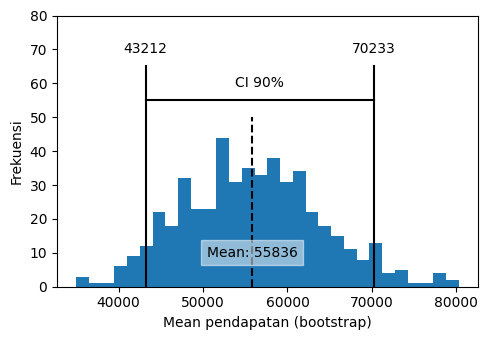

In [10]:
ax = results.plot.hist(bins=30, figsize=(5, 3.5))
ax.plot(confidence_interval, [55, 55], color='black')
for x in confidence_interval:
    ax.plot([x, x], [0, 65], color='black')
    ax.text(x, 70, f'{x:.0f}', horizontalalignment='center', verticalalignment='center')
ax.text(sum(confidence_interval) / 2, 60, 'CI 90%', horizontalalignment='center', verticalalignment='center')

mean_income = results.mean()
ax.plot([mean_income, mean_income], [0, 50], color='black', linestyle='--')
ax.text(mean_income, 10, f'Mean: {mean_income:.0f}', bbox=dict(facecolor='white', edgecolor='white', alpha=0.5),
        horizontalalignment='center', verticalalignment='center')
ax.set_ylim(0, 80)
ax.set_xlabel('Mean pendapatan (bootstrap)')
ax.set_ylabel('Frekuensi')
plt.tight_layout(); plt.show()

## 6. Distribusi Normal

Distribusi normal (kurva lonceng / Gaussian) sangat penting dalam statistik klasik karena distribusi banyak **statistik sampel** mendekati normal (berkat CLT).

**Istilah kunci:**
- **Error** — selisih antara data dan nilai prediksi/rata-rata.
- **Standardize** — kurangi mean lalu bagi dengan standar deviasi.
- **z-score** — hasil standardisasi satu data point.
- **Standard normal** — distribusi normal dengan mean 0 dan SD 1.
- **QQ-plot** — plot untuk membandingkan distribusi sampel dengan distribusi tertentu (misalnya normal).

Pada distribusi normal:
- ±1 SD dari mean memuat sekitar **68%** data,
- ±2 SD memuat sekitar **95%** data.

**Kesalahpahaman umum:** distribusi normal disebut "normal" bukan karena kebanyakan data dunia nyata berdistribusi normal. Justru **data mentah biasanya tidak normal**. Kegunaan utamanya adalah untuk distribusi *statistik* dan *error*.

### Standard Normal dan z-score
$$z = \frac{x - \bar{x}}{s}$$
Mengubah data ke z-score (*normalisasi/standardisasi*) tidak membuat data menjadi normal; ia hanya menaruh semua variabel di skala yang sama agar bisa dibandingkan.

### QQ-Plot
QQ-plot menaruh z-score data yang sudah diurutkan (sumbu y) terhadap kuantil distribusi normal (sumbu x). **Jika titik-titik mengikuti garis diagonal, datanya mendekati normal.**

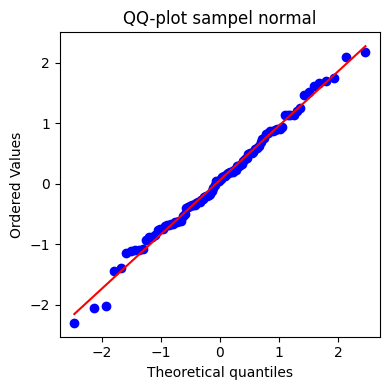

In [11]:
# Figure 2-11: QQ-plot untuk 100 sampel dari distribusi normal
fig, ax = plt.subplots(figsize=(4, 4))
norm_sample = stats.norm.rvs(size=100, random_state=1)
stats.probplot(norm_sample, plot=ax)
ax.set_title('QQ-plot sampel normal')
plt.tight_layout(); plt.show()

In [12]:
# Cek aturan 68-95
z = stats.norm.rvs(size=100_000, random_state=2)
print(f'Dalam ±1 SD: {np.mean(np.abs(z) < 1):.3f}')
print(f'Dalam ±2 SD: {np.mean(np.abs(z) < 2):.3f}')

Dalam ±1 SD: 0.684
Dalam ±2 SD: 0.953


## 7. Distribusi Long-Tailed

**Istilah kunci:**
- **Tail** — bagian ujung distribusi yang panjang dan sempit, tempat nilai ekstrem relatif jarang muncul.
- **Skew** — satu ekor lebih panjang daripada yang lain.

Banyak data dunia nyata **tidak** normal. Contohnya:
- Pendapatan → miring (skewed).
- Data kategorikal atau biner → jelas tidak normal.
- **Return saham harian** → simetris, tapi ekornya **lebih tebal** daripada normal (*fat tails*). Artinya kejadian ekstrem jauh lebih sering daripada yang diprediksi distribusi normal.

Mengasumsikan normal pada data long-tailed bisa berbahaya, misalnya **meremehkan risiko kejadian ekstrem** (contoh yang diangkat penulis: konsep *black swan* dari Nassim Taleb).

Contoh dari buku: QQ-plot log-return harian saham Netflix (NFLX).

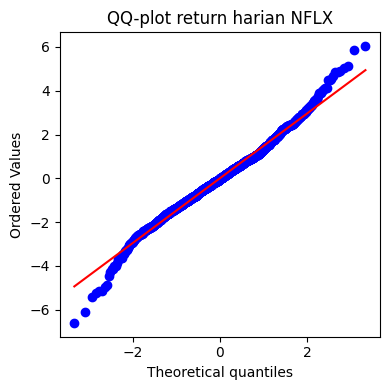

In [13]:
sp500_px = pd.read_csv(DATA + 'sp500_data.csv.gz', index_col=0)

nflx = sp500_px.NFLX
nflx = np.diff(np.log(nflx[nflx > 0]))   # log-return harian

fig, ax = plt.subplots(figsize=(4, 4))
stats.probplot(nflx, plot=ax)
ax.set_title('QQ-plot return harian NFLX')
plt.tight_layout(); plt.show()

Berbeda dengan sampel normal di atas, titik-titik di kedua ujung **menjauh** dari garis diagonal: di kiri bawah lebih rendah, di kanan atas lebih tinggi. Artinya return ekstrem (naik maupun turun) jauh lebih sering daripada yang diprediksi distribusi normal.

In [14]:
# Perbandingan: berapa banyak return yang melewati 3 SD?
z_nflx = (nflx - nflx.mean()) / nflx.std()
print(f'Proporsi |z| > 3 pada NFLX   : {np.mean(np.abs(z_nflx) > 3):.4f}')
print(f'Proporsi |z| > 3 jika normal : {2 * stats.norm.sf(3):.4f}')

Proporsi |z| > 3 pada NFLX   : 0.0124
Proporsi |z| > 3 jika normal : 0.0027


## 8. Distribusi t (Student's t)

Distribusi t bentuknya mirip normal, tapi **ekornya sedikit lebih tebal**. Ditemukan oleh W.S. Gosset (dengan nama samaran "Student") saat bekerja di pabrik bir Guinness.

**Istilah kunci:**
- **n** — ukuran sampel.
- **Degrees of freedom (df)** — parameter yang menyesuaikan distribusi t dengan ukuran sampel.

**Kegunaan:**
- Menggambarkan distribusi **mean sampel** ketika ukuran sampel kecil dan standar deviasi populasi tidak diketahui.
- Semakin besar sampel (df), distribusi t semakin mirip normal.
- Confidence interval klasik untuk mean:
$$\bar{x} \pm t_{n-1}(0.05) \cdot \frac{s}{\sqrt{n}}$$
- Dipakai juga di uji-t (perbandingan dua mean) dan untuk parameter regresi.

Di data science, perhitungan distribusi t jarang dilakukan manual karena software sudah melakukannya, dan bootstrap sering bisa menggantikannya.

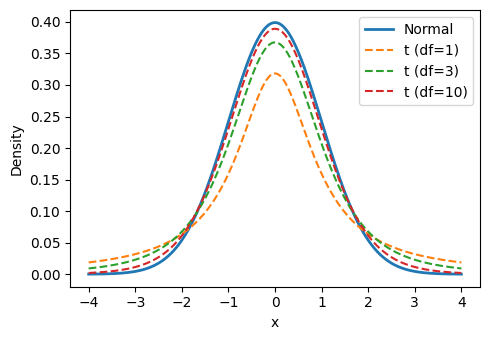

In [15]:
x = np.linspace(-4, 4, 400)
fig, ax = plt.subplots(figsize=(5, 3.5))
ax.plot(x, stats.norm.pdf(x), label='Normal', lw=2)
for df in [1, 3, 10]:
    ax.plot(x, stats.t.pdf(x, df), label=f't (df={df})', ls='--')
ax.set_xlabel('x'); ax.set_ylabel('Density'); ax.legend()
plt.tight_layout(); plt.show()

In [16]:
# CI 90% klasik (pakai distribusi t) untuk sampel 20 tadi — bandingkan dengan CI bootstrap
n = len(sample20)
se = sample20.std() / np.sqrt(n)
t_crit = stats.t.ppf(0.95, df=n - 1)
print('CI 90% (t)        :', [round(sample20.mean() - t_crit * se), round(sample20.mean() + t_crit * se)])
print('CI 90% (bootstrap):', [round(x) for x in confidence_interval])

CI 90% (t)        : [41236, 70233]
CI 90% (bootstrap): [43212, 70233]


## 9. Distribusi Binomial

**Istilah kunci:**
- **Trial** — satu kejadian dengan hasil diskrit (misalnya satu lemparan koin).
- **Success** — hasil yang kita minati (biasanya diberi nilai 1), meski tidak harus "baik".
- **Binomial** — punya dua kemungkinan hasil (ya/tidak, 0/1).
- **Binomial trial** — trial dengan dua hasil (disebut juga *Bernoulli trial*).
- **Binomial distribution** — distribusi jumlah sukses dalam $n$ trial.

**Parameter:** $n$ (jumlah trial) dan $p$ (peluang sukses per trial).

- Mean: $n \times p$
- Varians: $n \times p (1-p)$

Distribusi binomial relevan untuk banyak kasus bisnis: apakah pengunjung membeli atau tidak, apakah klik atau tidak, apakah transaksi fraud atau bukan.

Jika $n$ besar dan $p$ tidak terlalu dekat 0 atau 1, distribusi binomial bisa **didekati dengan distribusi normal**.

In [17]:
# Peluang tepat 2 sukses dari 5 trial, p = 0.1
print('P(X = 2)  :', stats.binom.pmf(2, n=5, p=0.1))
# Peluang paling banyak 2 sukses
print('P(X <= 2) :', stats.binom.cdf(2, n=5, p=0.1))

P(X = 2)  : 0.07289999999999992
P(X <= 2) : 0.99144


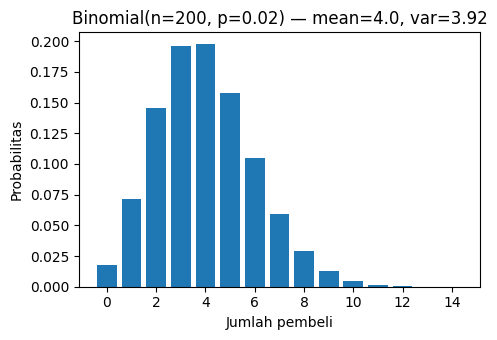

In [18]:
# Contoh bisnis: 200 pengunjung, peluang beli 2%
n, p = 200, 0.02
k = np.arange(0, 15)
fig, ax = plt.subplots(figsize=(5, 3.5))
ax.bar(k, stats.binom.pmf(k, n, p))
ax.set_xlabel('Jumlah pembeli'); ax.set_ylabel('Probabilitas')
ax.set_title(f'Binomial(n={n}, p={p}) — mean={n*p}, var={n*p*(1-p):.2f}')
plt.tight_layout(); plt.show()

## 10. Distribusi Chi-Square dan F

### Chi-square ($\chi^2$)
Mengukur seberapa jauh data yang diamati **menyimpang dari yang diharapkan** di bawah asumsi tertentu (biasanya asumsi "tidak ada hubungan" atau independensi antar variabel).

Statistik chi-square berbasis selisih (observasi − ekspektasi), dikuadratkan, lalu dinormalisasi. Distribusi chi-square adalah distribusi statistik ini jika data diambil berulang dari model yang independen. Nilai yang kecil → data cocok dengan ekspektasi; nilai besar → ada penyimpangan yang mungkin berarti.

Contoh: apakah jumlah pembelian sama pada beberapa varian halaman web? Detailnya dibahas di Bab 3.

### Distribusi F
Mirip ide chi-square, tapi untuk data numerik kontinu. Statistik F adalah **rasio variabilitas antar kelompok terhadap variabilitas dalam kelompok** (dikenal dari **ANOVA**). Juga dipakai di regresi linear untuk membandingkan variasi yang dijelaskan model dengan variasi error. Dibahas lebih lanjut di Bab 3 dan 4.

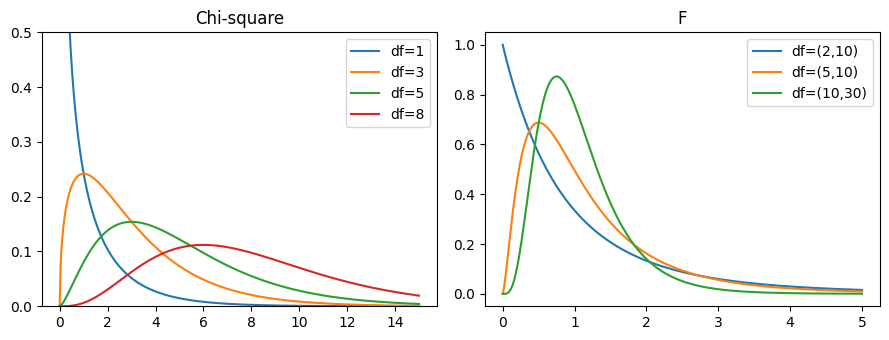

In [19]:
x = np.linspace(0, 15, 400)
fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
for df in [1, 3, 5, 8]:
    axes[0].plot(x, stats.chi2.pdf(x, df), label=f'df={df}')
axes[0].set_ylim(0, 0.5); axes[0].set_title('Chi-square'); axes[0].legend()

x = np.linspace(0, 5, 400)
for d1, d2 in [(2, 10), (5, 10), (10, 30)]:
    axes[1].plot(x, stats.f.pdf(x, d1, d2), label=f'df=({d1},{d2})')
axes[1].set_title('F'); axes[1].legend()
plt.tight_layout(); plt.show()

## 11. Distribusi Poisson dan Turunannya

Banyak proses menghasilkan kejadian secara acak dengan laju rata-rata tertentu: pengunjung web per detik, mobil yang lewat gerbang tol per menit, keluhan pelanggan per hari.

**Istilah kunci:**
- **Lambda ($\lambda$)** — laju kejadian per satuan waktu/ruang.
- **Poisson distribution** — distribusi **jumlah kejadian** per satuan waktu/ruang.
- **Exponential distribution** — distribusi **waktu/jarak antar kejadian**.
- **Weibull distribution** — versi umum eksponensial, di mana laju kejadian boleh **berubah seiring waktu**.

### Poisson
Parameter tunggal: $\lambda$, yang sekaligus merupakan **mean dan varians** distribusinya.
Contoh penggunaan: memperkirakan kapasitas yang dibutuhkan, misalnya berapa agen call center yang harus disiapkan agar 95% waktu bisa melayani semua panggilan.

In [20]:
# 100 bilangan acak Poisson dengan lambda = 2
print(stats.poisson.rvs(2, size=100, random_state=0)[:20])

# Contoh kapasitas: rata-rata 2 panggilan/menit.
# Berapa kapasitas per menit agar cukup di 95% waktu?
print('Kapasitas 95%:', stats.poisson.ppf(0.95, mu=2), 'panggilan/menit')

[3 2 5 1 0 0 7 1 3 3 5 2 2 0 1 3 1 2 1 0]
Kapasitas 95%: 5.0 panggilan/menit


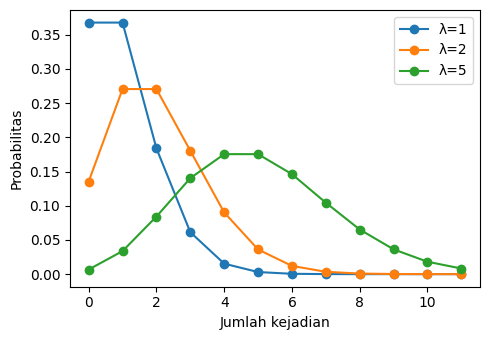

In [21]:
k = np.arange(0, 12)
fig, ax = plt.subplots(figsize=(5, 3.5))
for lam in [1, 2, 5]:
    ax.plot(k, stats.poisson.pmf(k, lam), marker='o', label=f'λ={lam}')
ax.set_xlabel('Jumlah kejadian'); ax.set_ylabel('Probabilitas'); ax.legend()
plt.tight_layout(); plt.show()

### Exponential
Dengan parameter $\lambda$ yang sama, distribusi eksponensial memodelkan **waktu antar kejadian**. Contoh: waktu antar kunjungan ke website, atau waktu sampai sebuah mesin rusak. Mean-nya $1/\lambda$.

**Asumsi penting** (baik untuk Poisson maupun eksponensial): laju $\lambda$ konstan selama periode yang dipertimbangkan. Di dunia nyata ini jarang persis benar (lalu lintas web berbeda antara siang dan malam), tapi periodenya sering bisa dibagi-bagi menjadi potongan yang cukup homogen.

Rata-rata waktu antar kejadian: 4.59


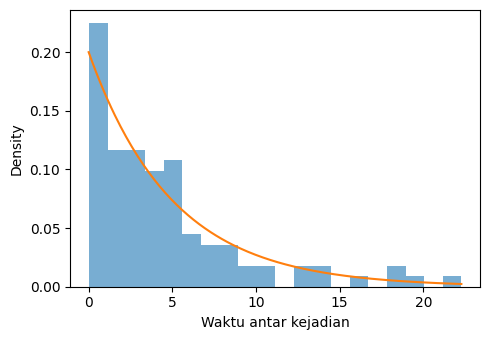

In [22]:
# 100 bilangan acak eksponensial, rata-rata 0.2 kejadian per periode → scale = 1/0.2 = 5
waktu = stats.expon.rvs(scale=1/0.2, size=100, random_state=0)
print('Rata-rata waktu antar kejadian:', waktu.mean().round(2))

fig, ax = plt.subplots(figsize=(5, 3.5))
ax.hist(waktu, bins=20, density=True, alpha=0.6)
x = np.linspace(0, waktu.max(), 200)
ax.plot(x, stats.expon.pdf(x, scale=5))
ax.set_xlabel('Waktu antar kejadian'); ax.set_ylabel('Density')
plt.tight_layout(); plt.show()

### Estimasi Laju Kegagalan (Failure Rate)
Untuk kejadian yang **sangat jarang** (misalnya kecelakaan pesawat), data mungkin hampir tidak ada. Pendekatan praktis dari buku:
- Kalau belum pernah terjadi dalam 20 jam, kita setidaknya tahu lajunya kemungkinan besar bukan 1 per jam.
- Kita bisa **menyimulasikan** atau menghitung probabilitas berbagai kandidat laju, lalu melihat laju mana yang cukup masuk akal dengan data yang ada.

### Weibull
Jika laju kejadian **berubah seiring waktu** (misalnya risiko kerusakan mesin meningkat karena usia), eksponensial tidak lagi cocok. Weibull menangani ini dengan tambahan **shape parameter** $\beta$:
- $\beta > 1$ → laju kegagalan **meningkat** seiring waktu (aus/penuaan).
- $\beta < 1$ → laju kegagalan **menurun** (misalnya cacat bawaan yang muncul di awal).
- $\beta = 1$ → sama dengan eksponensial.

Parameter kedua adalah **scale** $\eta$ (disebut juga *characteristic life*). Weibull banyak dipakai di rekayasa keandalan (*reliability engineering*) dan **survival analysis**.

[ 4294.  5820.  4741.  4263.  3361.  5126.  3459.  8518. 11116.  3081.]


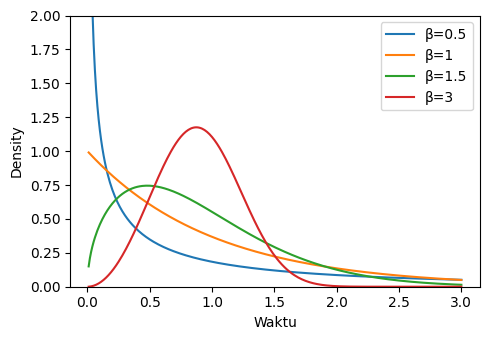

In [23]:
# 10 bilangan acak Weibull, shape = 1.5, scale = 5000
print(stats.weibull_min.rvs(1.5, scale=5000, size=10, random_state=0).round(0))

x = np.linspace(0.01, 3, 300)
fig, ax = plt.subplots(figsize=(5, 3.5))
for beta in [0.5, 1, 1.5, 3]:
    ax.plot(x, stats.weibull_min.pdf(x, beta), label=f'β={beta}')
ax.set_ylim(0, 2); ax.set_xlabel('Waktu'); ax.set_ylabel('Density'); ax.legend()
plt.tight_layout(); plt.show()

## Ringkasan Bab 2

- **Kualitas sampel lebih penting daripada ukurannya.** Random sampling mengurangi bias; stratified sampling menjamin keterwakilan kelompok.
- Waspadai **selection bias**, **data snooping**, dan **vast search effect**. Gunakan holdout set untuk memvalidasi temuan.
- **Regression to the mean**: performa ekstrem cenderung diikuti performa yang lebih mendekati rata-rata.
- **Sampling distribution** menggambarkan variasi sebuah statistik antar sampel; **standard error** adalah standar deviasinya, dan mengecil sebanding $\sqrt{n}$.
- **Central limit theorem**: mean sampel cenderung normal untuk sampel besar.
- **Bootstrap** (resampling dengan pengembalian) adalah cara serbaguna mengestimasi SE dan **confidence interval** untuk statistik apa pun, tanpa asumsi normalitas.
- **Distribusi normal** penting untuk statistik dan error, tapi **data mentah sering tidak normal** dan bisa **long-tailed**. Cek dengan **QQ-plot**.
- **Distribusi t** untuk mean sampel kecil; **binomial** untuk hasil ya/tidak; **chi-square** dan **F** untuk menguji penyimpangan dari ekspektasi (dibahas lanjut di Bab 3).
- **Poisson** (jumlah kejadian), **eksponensial** (waktu antar kejadian), dan **Weibull** (laju kejadian yang berubah) untuk memodelkan kejadian acak.

Pesan utama: di data science, **simulasi dan bootstrap** sering lebih praktis daripada rumus teoretis, tapi memahami distribusi-distribusi ini membantu memilih model dan menghindari asumsi yang keliru.